## Objective
The objective of this notebook is to apply descriptive statistics, probability distributions,
and hypothesis testing on the Sample Superstore dataset to validate business assumptions.

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [92]:
df = pd.read_csv(
    "/workspaces/Data_Science_Internship/Week_3/Sample - Superstore.csv",
    encoding="latin1"
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [93]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [94]:
df[['Sales', 'Profit']].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


In [95]:
df[['Sales', 'Profit']].skew()

Sales     12.972752
Profit     7.561432
dtype: float64

In [96]:
df[['Sales', 'Profit']].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


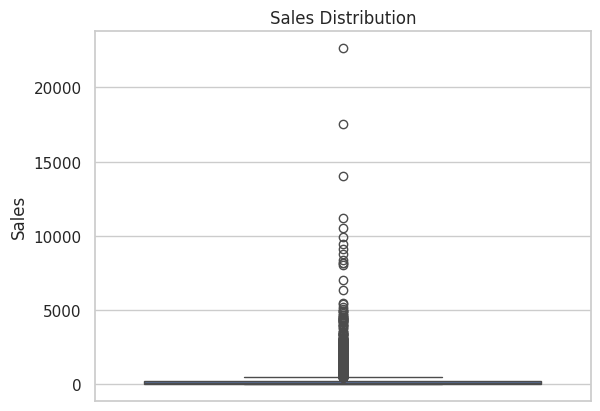

In [100]:
plt.figure()
sns.boxplot(df['Sales'])
plt.title("Sales Distribution")
plt.show()

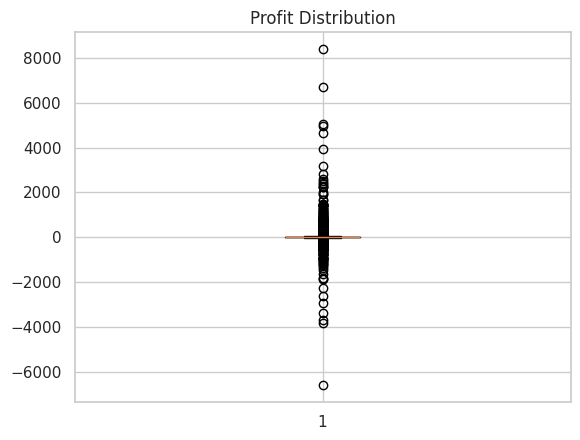

In [98]:
plt.boxplot(df['Profit'])
plt.title("Profit Distribution")
plt.show()

### Business Assumption
## Hypothesis Testing: Impact of Discount on Profit

### Business Question
Does offering higher discounts significantly reduce the profit generated from customer orders?

### Business Assumption
Higher discounts lead to lower profit.

### Hypotheses
- **Null Hypothesis (H₀):** Discount has no significant impact on profit.
- **Alternative Hypothesis (H₁):** Higher discounts significantly reduce profit.

### Test Performed
An **independent two-sample t-test (Welch’s t-test)** was conducted to compare the mean profit between:
- **Low-discount orders** (Discount ≤ median)
- **High-discount orders** (Discount > median)

This test was chosen because the two groups are independent and may have unequal variances.

In [99]:
median_discount = df['Discount'].median()

low_discount = df[df['Discount'] <= median_discount]['Profit']
high_discount = df[df['Discount'] > median_discount]['Profit']

t_stat, p_value = stats.ttest_ind(low_discount, high_discount, equal_var=False)

print(t_stat, p_value)

16.1409994038947 2.2951802592337516e-54


### Test Results
- **t-statistic:** 16.14  
- **p-value:** 2.29 × 10⁻⁵⁴  
- **Significance level (α):** 0.05

### Decision Rule
If the p-value is less than the significance level (0.05), reject the null hypothesis.

### Conclusion
Since the p-value is significantly smaller than 0.05, the null hypothesis is rejected.  
This provides strong statistical evidence that **higher discounts have a significant negative impact on profit**.

### Business Interpretation
From a business perspective, aggressive discounting strategies negatively affect profitability.  
Optimizing discount levels is crucial to maintaining profit margins while driving sales.